## <center>CITS5508 Assignment 2</center>

Author: Seng Qi Ming (25303739)

 - [Ensemble Learning for Heart Disease Prediction](#part-1-ensemble-learning-for-heart-disease-prediction)
 - [Clustering of Faces](#part-2-clustering-of-faces)

In this assignment we will first explore ensemble learning for heart disease prediction, followed by investigating how the effect of PCA with k-means clustering using the Olivetti Faces dataset from AT&T Laboratories Cambridge.

### Importing necessary libraries

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import graphviz

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

## Part 1: Ensemble Learning for Heart Disease Prediction

In this task, we will compare a range of ensemble methods for predicting the presence of heart disease in patients.

We will use the Heart Disease dataset from the UC Irvine Machine Learning Repository, available at: https://doi.org/10.24432/C52P4X.

### 1.1: Load the dataset & Inspect the data
We will first load the dataset using the `processed.cleveland.data`, from the source, the variables are as follows
| Variable Name | Role | Type | Description | Missing Values |
|---------------|-----|------|-------------|----------------|
| age           | Feature|Integer| | No|
| sex           | Feature|Categorical| | No |
| cp            | Feature|Categorical| | No |
| trestbps      | Feature| Integer| resting blood pressure (on admission to the hospital)| No |
| chol      | Feature| Integer| serum cholestoral | No |
| fbs      | Feature| Categorical | fasting blood sugar > 120 mg/dl| No |
| restecg      | Feature| Categorical | | No |
| thalach      | Feature| Integer| maximum heart rate achieved | No |
| exang      | Feature| Categorical | exercise induced angina| No |
| oldpeak      | Feature| Integer| ST depression induced by exercise relative to rest | No |
| slope      | Feature| Categorical| | No |
| ca      | Feature| Integer| number of major vessels (0-3) coloured by flourosopy| Yes |
| thal      | Feature| Categorical| | Yes |
| num      | Target| Integer| diagnosis of heart disease| No |

The target variable (`num`) originally contains integer values from 0 to 4, representing the number of major vessels with significant narrowing. Following the assignment specification, we will binarise it: 0 indicates the absence of heart disease, and 1 (any value > 0) indicates its presence.

In [ ]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

data = pd.read_csv('processed.cleveland.data', names=column_names, na_values='?')

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [ ]:
n_examples = data.shape[0]
n_features = data.shape[1]

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print(f'Number of examples: {n_examples}')
print(f'Number of features (including target): {n_features}')
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')

data['num_binary'] = (data['num'] > 0).astype(int)
print('Target distribution (original):')
print(data['num'].value_counts().sort_index())
print('Target distribution (binary):')
print(data['num_binary'].value_counts().sort_index())

Number of examples: 303
Number of features (including target): 14
Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Target distribution (original):
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
Target distribution (binary):
num_binary
0    164
1    139
Name: count, dtype: int64


#### Observation
- **Dataset**: 303 examples or patients with 13 features.
- **Numeric**: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`.
- **Categorical**: `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`.
- **Target**: Binarised (1 = presence of heart disease, 0 = absence).

### 1.2 Splitting of dataset

Next, we will split the dataset into a training and testing set, with 80% of the data for training, and 20% for
testing with stratification. 

In [ ]:
print(f'Row with missing data: {data.isna().any(axis=1).sum()}')
data = data.dropna()
print(f'Remaining rows: {len(data)}')

Row with missing data: 6
Remaining rows: 297


As only 6 rows contain incomplete data, we will proceed to drop them.

Next, we encode the categorical features. Even though they are stored as `float64`, these values are category IDs, not measured continuous quantities. If left as numeric codes, models may treat them as ordered or assume meaningful distances (e.g., 0.9 being ‘more male’ than 0.6), which is incorrect.

One-hot encoding removes this artificial ordering and allows the model to learn a separate effect for each category.

In [ ]:
data_labeled = data.copy()

data_labeled["sex"] = data_labeled["sex"].map({0: "is_female", 1: "is_male"})
data_labeled["cp"] = data_labeled["cp"].map({
    1: "typical",
    2: "atypical",
    3: "non_anginal",
    4: "asymptomatic",
})
data_labeled["fbs"] = data_labeled["fbs"].map({0: "no", 1: "yes"})
data_labeled["restecg"] = data_labeled["restecg"].map({
    0: "normal",
    1: "st_t_abnormal",
    2: "lv_hypertrophy",
})
data_labeled["exang"] = data_labeled["exang"].map({0: "no", 1: "yes"})
data_labeled["slope"] = data_labeled["slope"].map({1: "upsloping", 2: "flat", 3: "downsloping"})
data_labeled["thal"] = data_labeled["thal"].map({3: "normal", 6: "fixed_defect", 7: "reversable_defect"})

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="if_binary")
df_encoded_np = encoder.fit_transform(data_labeled[categorical_features])

df_encoded = pd.DataFrame(
    df_encoded_np,
    columns=encoder.get_feature_names_out(categorical_features),
    index=data.index,
)

print(df_encoded)

     sex_is_male  cp_asymptomatic  cp_atypical  cp_non_anginal  cp_typical  \
0            1.0              0.0          0.0             0.0         1.0   
1            1.0              1.0          0.0             0.0         0.0   
2            1.0              1.0          0.0             0.0         0.0   
3            1.0              0.0          0.0             1.0         0.0   
4            0.0              0.0          1.0             0.0         0.0   
..           ...              ...          ...             ...         ...   
297          0.0              1.0          0.0             0.0         0.0   
298          1.0              0.0          0.0             0.0         1.0   
299          1.0              1.0          0.0             0.0         0.0   
300          1.0              1.0          0.0             0.0         0.0   
301          0.0              0.0          1.0             0.0         0.0   

     fbs_yes  restecg_lv_hypertrophy  restecg_normal  restecg_s

In [ ]:
data_concat = pd.concat([data, df_encoded], axis=1)

data_concat = data_concat.drop(columns=categorical_features + ['num'])

print(f'{data_concat.columns}')

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'num_binary',
       'sex_is_male', 'cp_asymptomatic', 'cp_atypical', 'cp_non_anginal',
       'cp_typical', 'fbs_yes', 'restecg_lv_hypertrophy', 'restecg_normal',
       'restecg_st_t_abnormal', 'exang_yes', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed_defect', 'thal_normal',
       'thal_reversable_defect'],
      dtype='object')


Now since the data pre-processing is done, we will proceed to do the data splitting.

In [ ]:
X = data_concat.drop(columns=['num_binary'])
y = data_concat['num_binary']
print(f'X columns: {X.columns}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

X columns: Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex_is_male',
       'cp_asymptomatic', 'cp_atypical', 'cp_non_anginal', 'cp_typical',
       'fbs_yes', 'restecg_lv_hypertrophy', 'restecg_normal',
       'restecg_st_t_abnormal', 'exang_yes', 'slope_downsloping', 'slope_flat',
       'slope_upsloping', 'thal_fixed_defect', 'thal_normal',
       'thal_reversable_defect'],
      dtype='object')
Train samples: 237, Test samples: 60


### 1.3 Using a single Decision Tree classifier on our dataset

We will now fit a single Decision Tree classifier using scikit-learn as a baseline and evaluate its performance on the test set and compare it against the ensemble learning.

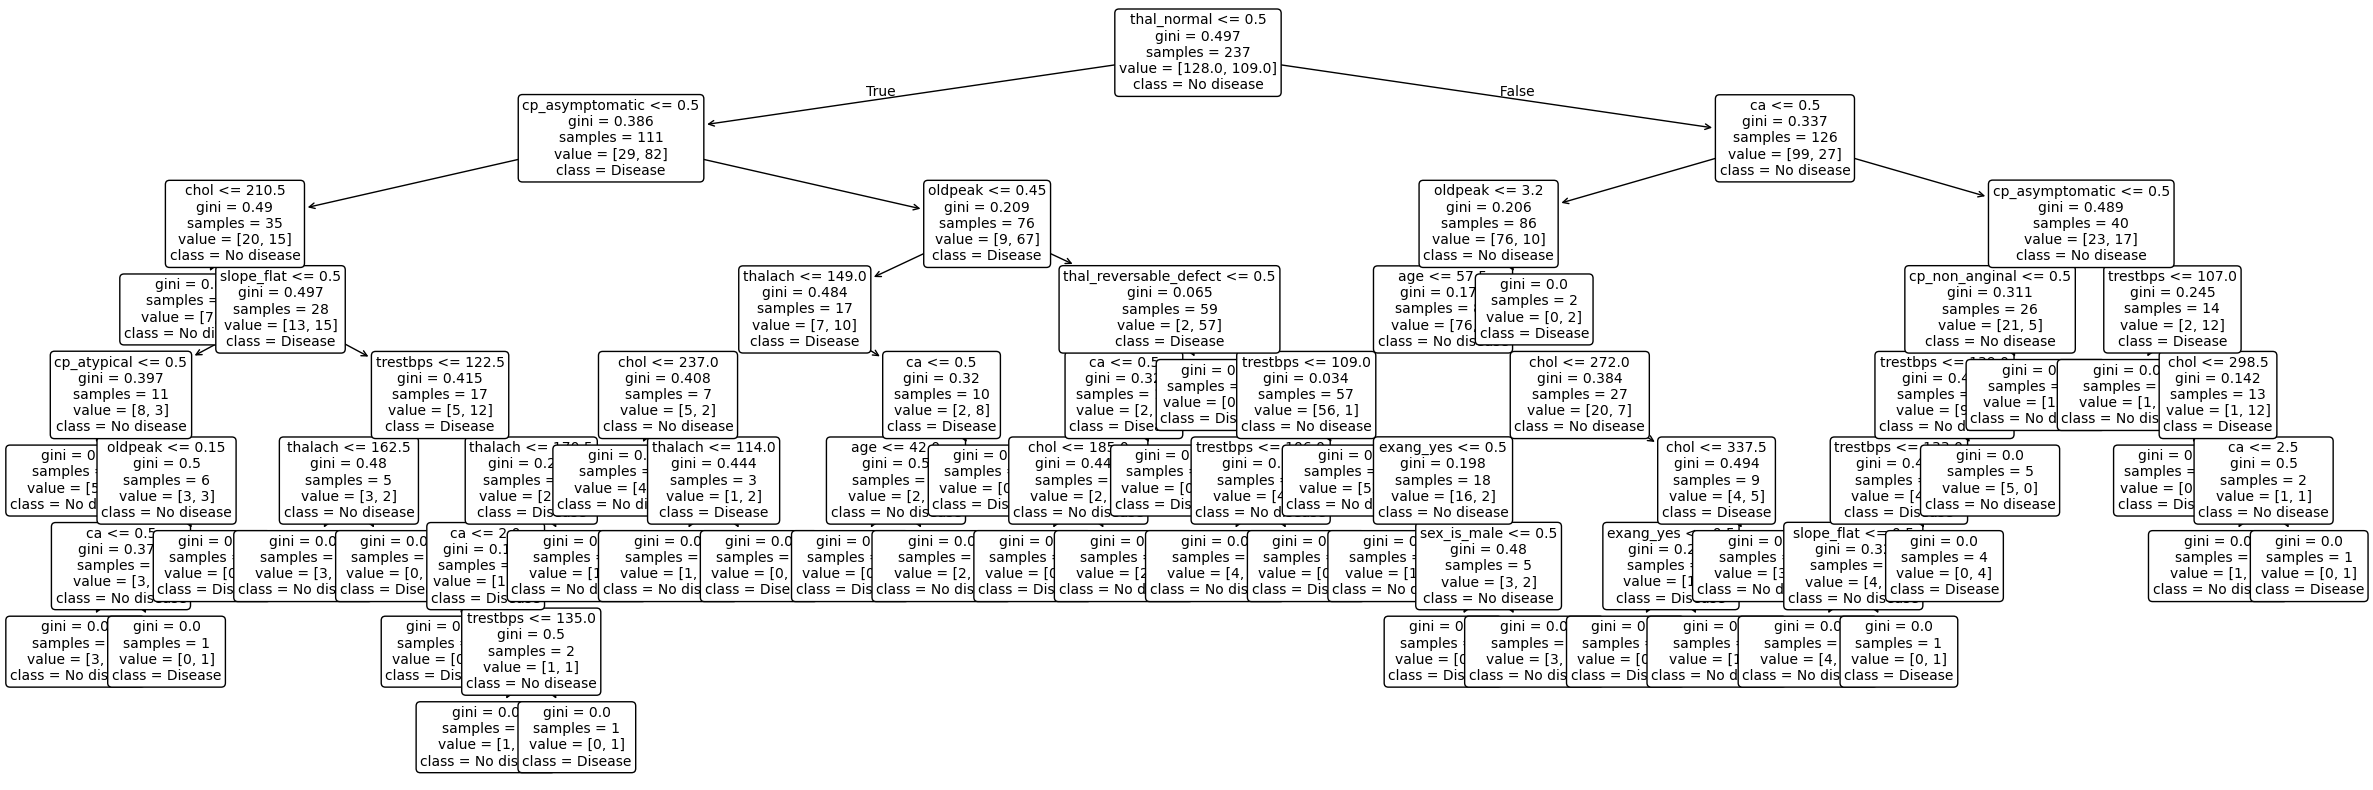

In [ ]:
# 1. Create the Matplotlib canvas (this will work now!)
plt.figure(figsize=(40, 20))

# 2. Plot the tree directly onto the canvas
tree.plot_tree(
    dt_clf,
    feature_names=X_test.columns,
    class_names=["No disease", "Disease"],
    filled=False,
    rounded=True,
    fontsize=10 # You can adjust the text size here
)

# 3. Show the plot
plt.show()

### 1.4 Fitting of Random Forest Classifier and AdaBoost Classifier

Next, we will be fitting 2 ensemble models using scikit-learn:
- Random Forest Classifier
- AdaBoost Classifier

Both model will use 500 as their estimators

In [ ]:
n_estimators=500

rf_clf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
rf_clf.fit(X_train, y_train)

ada_clf = AdaBoostClassifier(n_estimators=n_estimators,random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=500, random_state=42)

### 1.5 Combine your models from the previous steps in a soft-voting Voting Classifier

We will then proceed to combine the two fitted models from the previous step into a soft-voting Voting Classifier.

In [ ]:
voting_clf = VotingClassifier(estimators=[('rf_clf', rf_clf), ('ada_clf', ada_clf)], voting='soft')

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf_clf',
                              RandomForestClassifier(n_estimators=500,
                                                     random_state=42)),
                             ('ada_clf',
                              AdaBoostClassifier(n_estimators=500,
                                                 random_state=42))],
                 voting='soft')

### 1.6 Comparing model performance

Now that we have all the models fitted, we will create a table of metric which includes, precision, recall, F1 score, support as well as the confusion matrix for each model.

Note:
- Support refers to the count of true samples in each classes
- Accuracy - total correct / total samples
- Macro avg - Simple average of class scores (precision/ recall/ f1 score for class 0 & 1 averaged equally)
- Weighted avg - Average of class scores weighted by support (class 0 counts 32/ 60, class 1 counts 28/ 60)

In [ ]:
models = {'Decision Tree': dt_clf, 'Random Forest': rf_clf, 'AdaBoost': ada_clf, 'Voting Classifier':voting_clf}

reports = {}
for name, model in models.items():
    report = classification_report(y_test, model.predict(X_test), output_dict=True)
    reports[name] = pd.DataFrame(report).T  # rows: class/avg, cols: precision/recall/f1/support

side_by_side = pd.concat(reports, axis=1)
display(side_by_side)


Decision Tree                             Random Forest  \
                 precision    recall  f1-score support     precision   
0                 0.705882  0.750000  0.727273    32.0      0.823529   
1                 0.692308  0.642857  0.666667    28.0      0.846154   
accuracy          0.700000  0.700000  0.700000     0.7      0.833333   
macro avg         0.699095  0.696429  0.696970    60.0      0.834842   
weighted avg      0.699548  0.700000  0.698990    60.0      0.834087   

                                             AdaBoost                      \
                recall  f1-score    support precision    recall  f1-score   
0             0.875000  0.848485  32.000000  0.900000  0.843750  0.870968   
1             0.785714  0.814815  28.000000  0.833333  0.892857  0.862069   
accuracy      0.833333  0.833333   0.833333  0.866667  0.866667  0.866667   
macro avg     0.830357  0.831650  60.000000  0.866667  0.868304  0.866518   
weighted avg  0.833333  0.832772  60.000000  0.868889  0.866667  0.866815   

                        Voting Classifier                                 
                support         precision    recall  f1-score    support  
0             32.000000          0.823529  0.875000  0.848485  32.000000  
1             28.000000          0.846154  0.785714  0.814815  28.000000  
accuracy       0.866667          0.833333  0.833333  0.833333   0.833333  
macro avg     60.000000          0.834842  0.830357  0.831650  60.000000  
weighted avg  60.000000          0.834087  0.833333  0.832772  60.000000

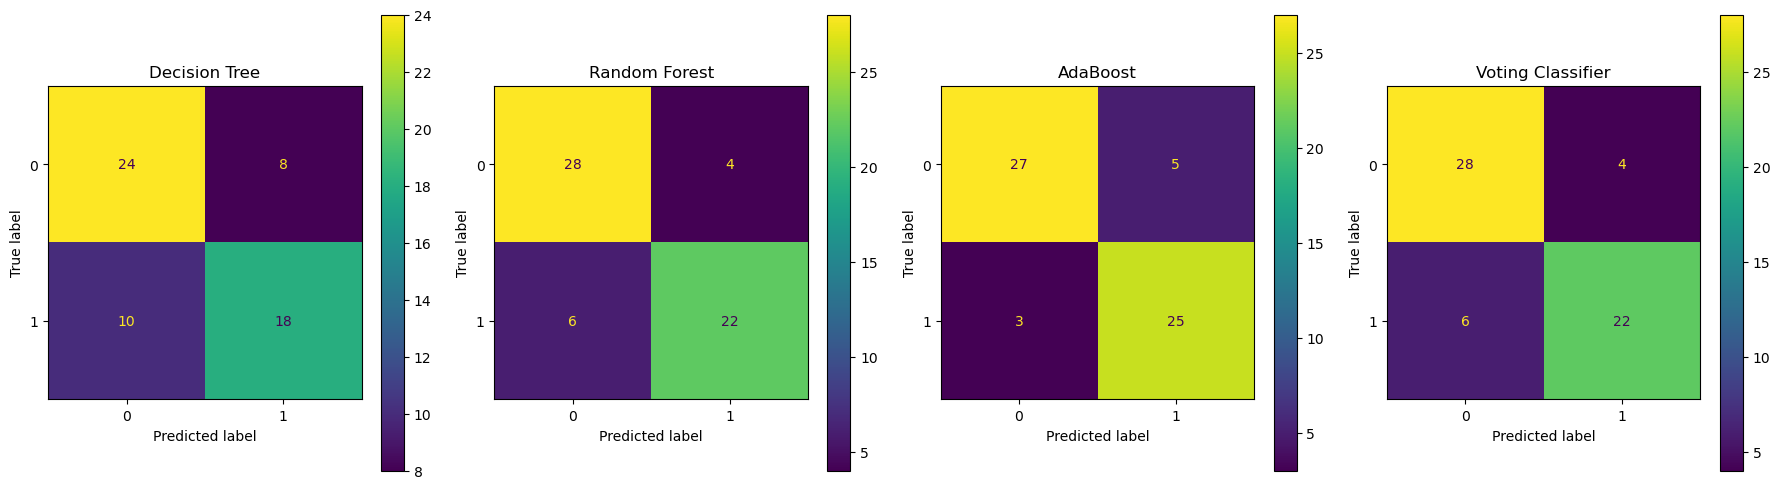

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### 1.7 Plot the feature importances of your Random Forest 

We now plot the Random Forest feature importances to see which features contribute most to the predictions.

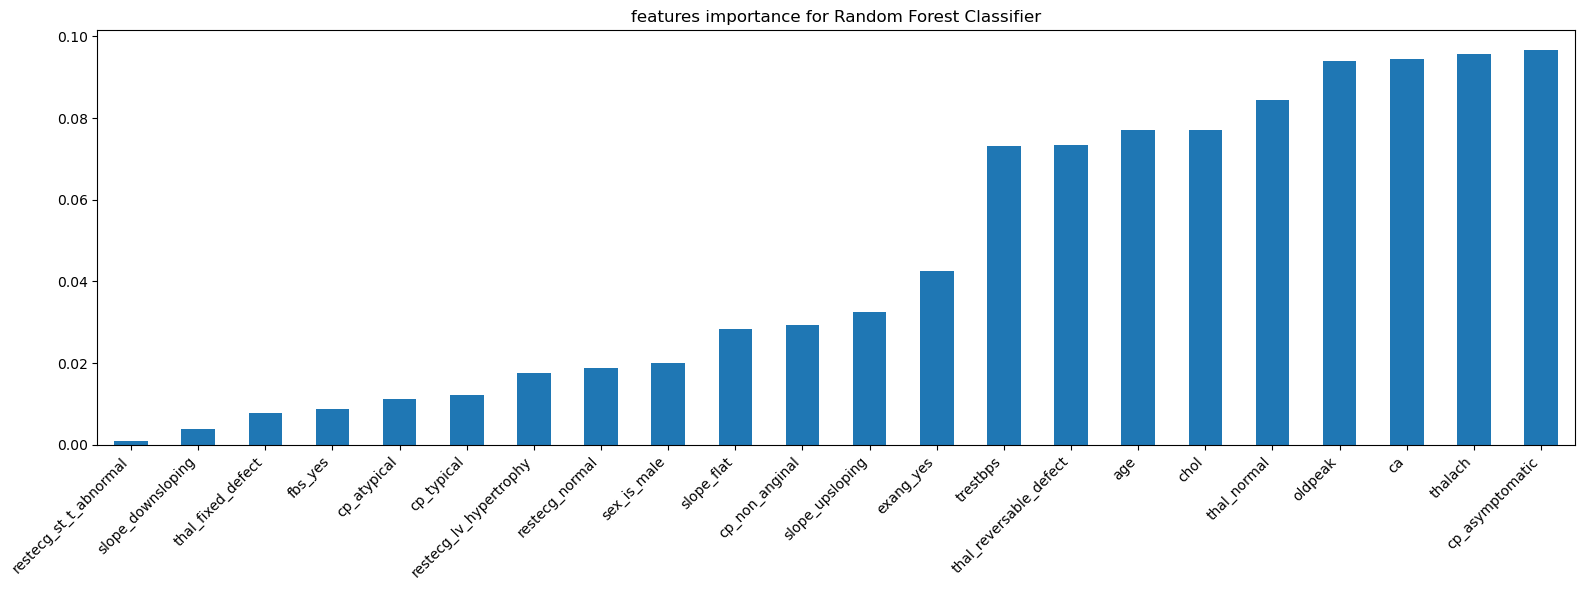

In [ ]:
feat_impt = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True)

feat_impt.plot(kind='bar', figsize=(16,6), title='features importance for Random Forest Classifier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
data['cp'].value_counts()

cp
4.0    142
3.0     83
2.0     49
1.0     23
Name: count, dtype: int64

From the feature-importance plot, we can see that `cp` (chest pain type), `thalach` (maximum heart rate), and `ca` (number of major vessels) are the most influential predictors in the model.  This makes intuitive sense, since chest pain is typically considered a primary indicator of heart disease. Within the `cp` feature, we notice that `cp_asymptomatic` stands out with the highest importance, which may partly reflect the dataset's composition, asymptomatic cases comprise 142 out of 297 examples (~48%).

Whereas, `restecg`, `slope`, and `thal` are the least influential features. This is somewhat surprising, as `restecg` (resting electrocardiographic results) is commonly used clinically to detect heart disease. However, this lower importance may indicate that `restecg` measurements are confounded by other factors in this dataset, which result in it being less relevant.

### 1.8 Observation & Comments


In [ ]:
rf_probs = rf_clf.predict_proba(X_test).max(axis=1).mean()
ada_probs = ada_clf.predict_proba(X_test).max(axis=1).mean()
vc_probs = voting_clf.predict_proba(X_test).max(axis=1).mean()


print(f"Random Forest mean max probability: {round(rf_probs, 3)}")
print(f"AdaBoost mean max probability:      {round(ada_probs, 3)}")
print(f"Voting Classifier mean max probability:      {round(vc_probs, 3)}")

Random Forest mean max probability: 0.799
AdaBoost mean max probability:      0.547
Voting Classifier mean max probability:      0.671


### 1.8 Observation & Comments

Across the four models, AdaBoost achieved the highest test accuracy (~86%), while the single Decision Tree baseline performed the worst (~70%). The Random Forest and the Voting Classifier produced identical results (~83% accuracy). This suggests that the Random Forest dominates the Voting Classifier's soft vote because its predicted probabilities carry much higher confidence.

When comparing the ensembles, Random Forest exhibits higher prediction confidence (higher mean max probability) than AdaBoost, yet AdaBoost slightly outperforms it in raw accuracy. Higher confidence reflects how strongly a model commits to its predictions, but it does not automatically guarantee better generalisation. 

The performance differences elegantly highlight the distinction between *bagging* and *boosting*:
- **Random Forest (Bagging):** Trains trees independently to reduce variance, making it highly stable and robust to small datasets or noisy features.
- **AdaBoost (Boosting):** Trains trees sequentially to reduce bias by focusing intensely on tough to predict examples. While this yielded the best accuracy on this test set, it can sometimes make the model more sensitive to outliers.

In conclusion, all ensemble methods heavily outperformed the single Decision Tree. Aggregating multiple models reduces the impact of individual errors and improves overall generalisation. While ensembles require significantly more computational resources (training 500 trees vs one), the substantial boost in predictive reliability makes the trade-off worthwhile.

## Part 2: Clustering of Faces

In this task, we investigate the Olivetti Faces dataset from AT&T Laboratories Cambridge using an unsupervised approach that combines Principal Component Analysis (PCA) with k‑Means Clustering

### 2.1 Load the dataset & Inspect the data

Based on sklearn's (`fetch_olivetti_faces().DESCR`) and  [sklearn documentation](https://scikit-learn.org/stable/datasets/real_world.html#olivetti-faces-dataset),

The Olivetti Faces dataset contains 400 grayscale face images across 40 classes (10 images per subject). The images were collected between April 1992 and April 1994 at AT&T Laboratories Cambridge. Each sample has 4096 features (a flattened 64 x 64 image), with pixel values scaled to the range [0, 1].

The dataset includes natural variation in capture conditions, such as lighting, facial expressions (for example, eyes open/ closed and smiling/ not smiling), and facial details (with/without glasses). All the images were taken against a dark
homogeneous background with the subjects in an upright, frontal position (with tolerance for some side movement).

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
X, y = fetch_olivetti_faces(return_X_y=True)

In [ ]:
print(f"Number of examples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]} (64x64)")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Images per class: {len(y) // len(np.unique(y))}")
print(f"Pixel value range: [{X.min():.1f}, {X.max():.1f}]")


Number of examples: 400
Number of features: 4096 (64x64)
Number of classes: 40
Images per class: 10
Pixel value range: [0.0, 1.0]


We got 400 examples and 4096 features.
Each example contains a picture of a face where each feature contain different style of a face.

### 2.2 Sample a random example from each class and display the images in a grid.

We will sample a random example from each class and display it below.

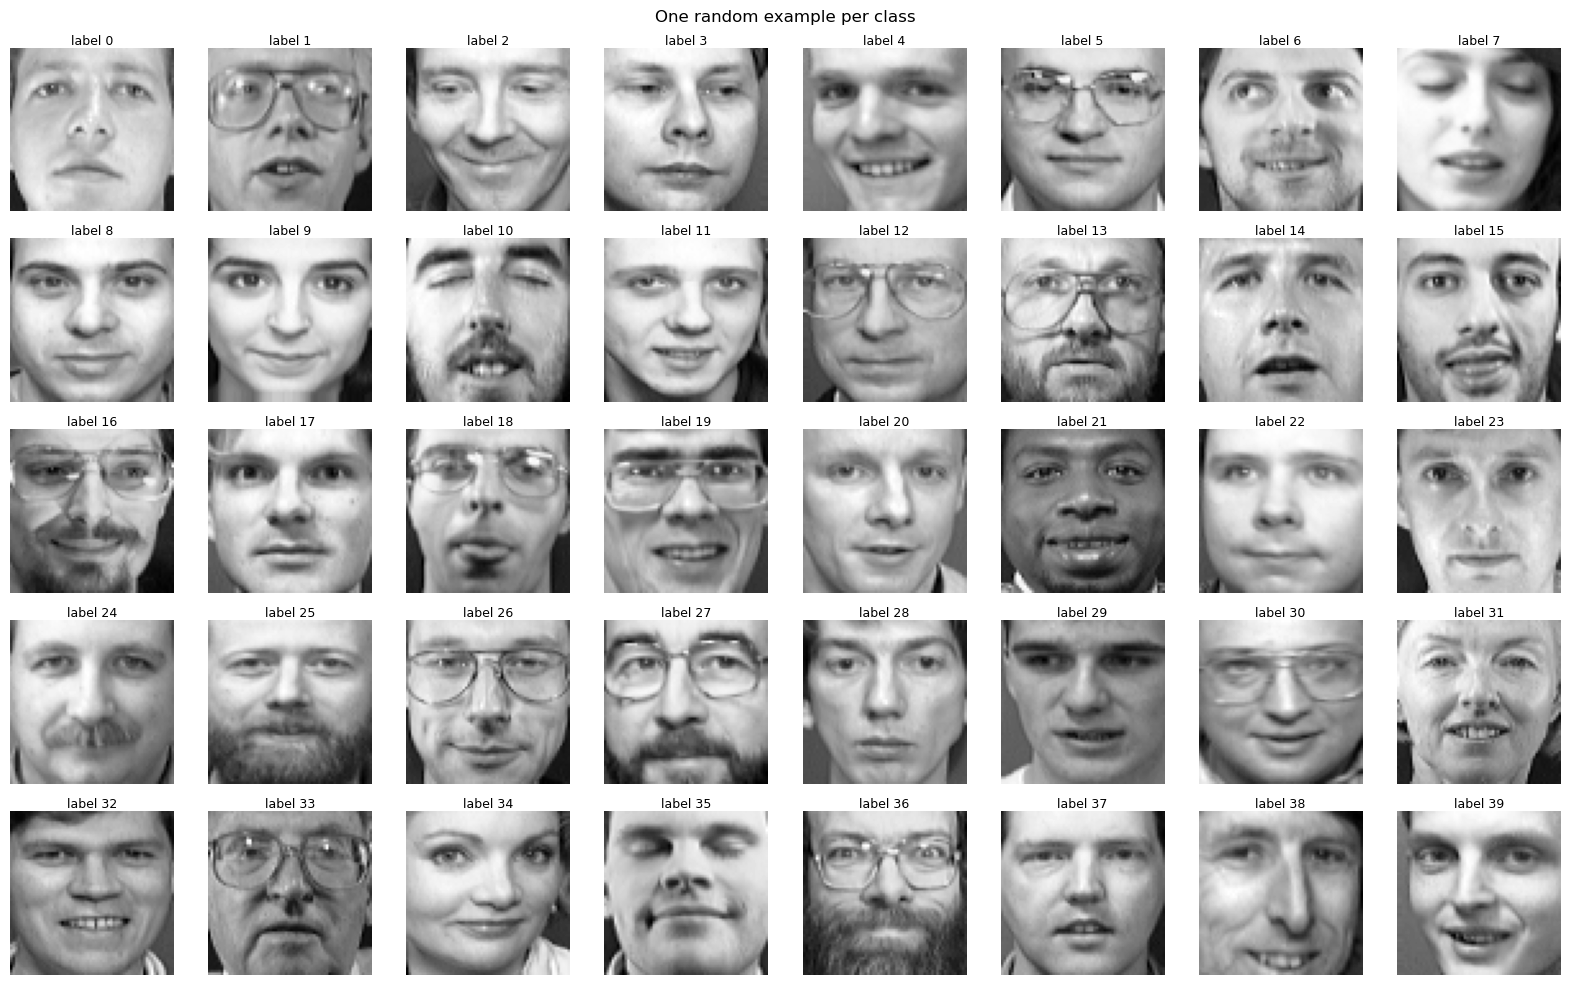

In [ ]:
np.random.seed(42)

classes = np.unique(y)
n_classes = len(classes)
n_cols = 8
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    idx = np.random.choice(np.where(y == cls)[0])
    img = X[idx].reshape(64, 64)  # 64 * 64 = 4096
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'label {cls}', pad=2, fontsize=9)
    axes[i].axis('off')

for j in range(n_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('One random example per class')
plt.tight_layout()
plt.show()

### 2.3 Fit Principal Component Analysis (PCA) on the full dataset using scikit-learn.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X)

PCA(random_state=42)

After fitting our PCA model on our dataset, we will proceed to plot the cumulative variance ratio against the number of components, We will also find or choose the components that retained >95% of the variance.

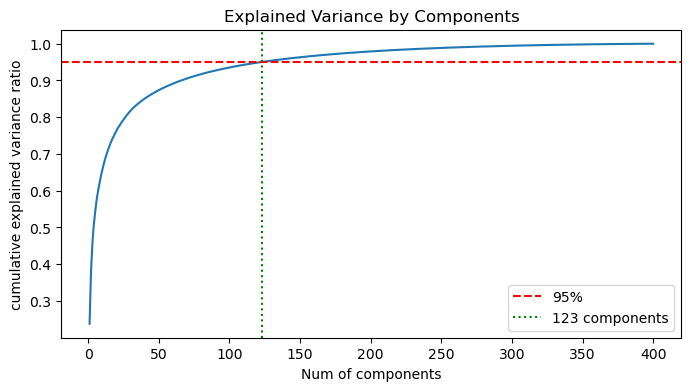

In [ ]:
# Calculate the min number of components to ensure it retains at least 95% of the variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, len(cumsum) + 1), cumsum, linewidth=1.5)
plt.axhline(0.95, color="r", linestyle="--", label="95%")
plt.axvline(d, color="g", linestyle=":", label=f"{d} components")
plt.xlabel('Num of components')
plt.ylabel('cumulative explained variance ratio')
plt.title('Explained Variance by Components')
plt.legend()
plt.show()

We can observe from the cumulative variance plot shows that 123 components are sufficient to retain over 95% of the variance. This represents a significant dimensionality reduction, compressing the original 4096 features into just 123 components which is around 3% of the original feature space.

Next, we will proceed to plot the first 10 principal components which is also called the *eigenfaces*.
Each eigenfaces is a principal components of a face dataset, reshaped as 64x64 images. Each component captures a common pattern across faces (e.g., lighting gradients, pose changes, or prominent facial structures). Any face image can be approximated as a weighted sum of these eigenfaces, so they provide a compact basis that explains most of the variance in the original images.

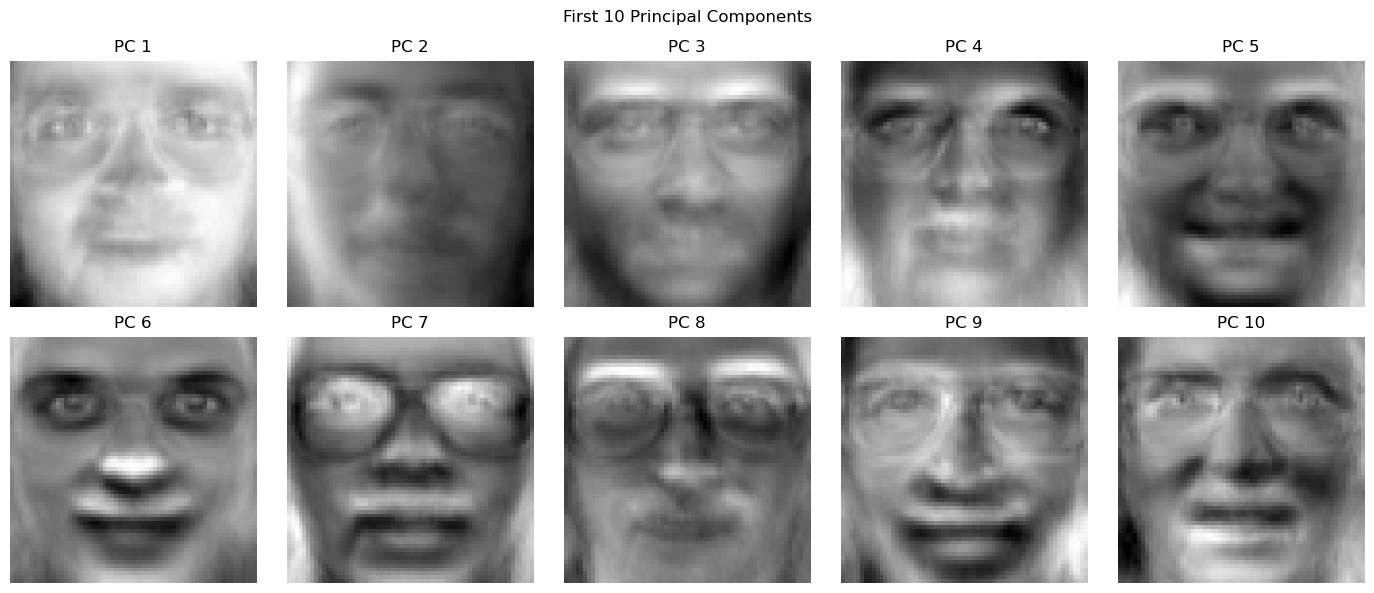

In [ ]:
fig, axes = plt.subplots(2,5, figsize=(14, 6))
for idx, axes in enumerate(axes.flatten()):
    img = pca.components_[idx].reshape(64, 64)  # 64 * 64 = 4096
    axes.imshow(img,  cmap='gray')
    axes.set_title(f'PC {idx + 1}', pad=6)
    axes.axis('off')
plt.suptitle('First 10 Principal Components')
plt.subplots_adjust(hspace=0.4, top=0.88)
plt.tight_layout()
plt.show()

Next we will proceed to plot the first two principal components onto a scatter plot

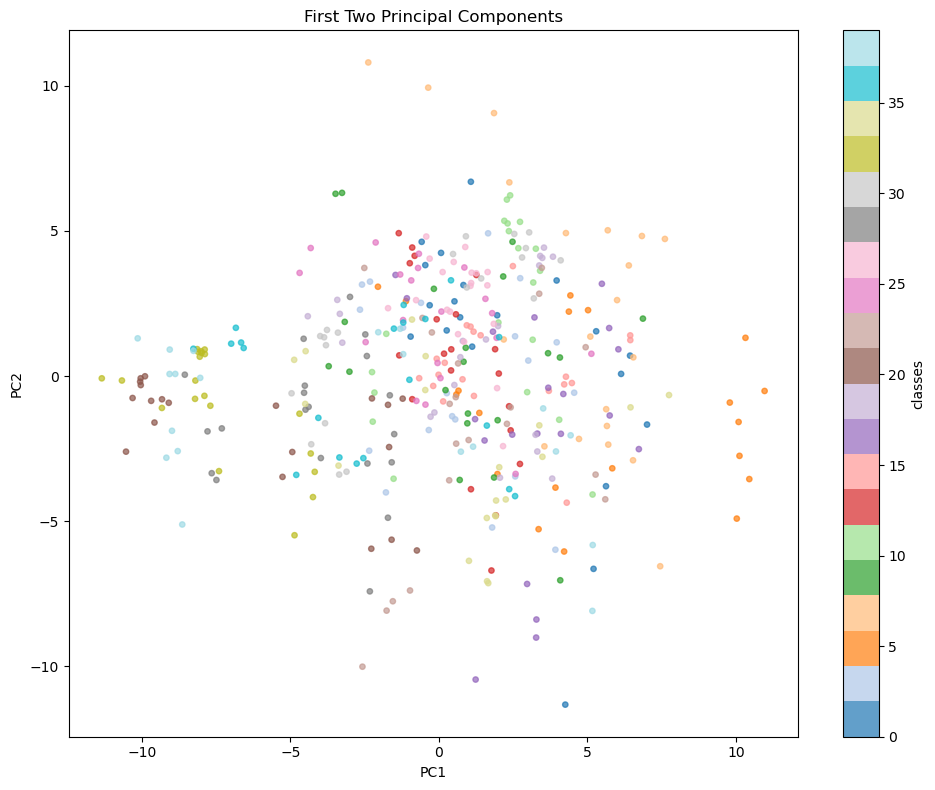

In [ ]:
# Project the data onto the first two principal components and produce a scatter plot, colouring each point by its class.
data_2d = pca.transform(X)[:, :2]

plt.figure(figsize=(10,8))
plt.scatter(data_2d[:,0],data_2d[:,1], c=y, cmap="tab20", s=15, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("First Two Principal Components")
plt.colorbar(label='classes')
plt.tight_layout()
plt.show()

We can observe that there are significant overlap of classes, With 2 dimensions we have no clear way to separate them. Therefore, it is evident with 2 components it is not sufficient to separate the classes.

### 2.4 Applying K-Means Clustering to the original feature space

Next, we will apply k-Means clustering to the original feature space, using k value equal to the number of classes.

In [ ]:
# Number of classes: 40
k = 40
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)

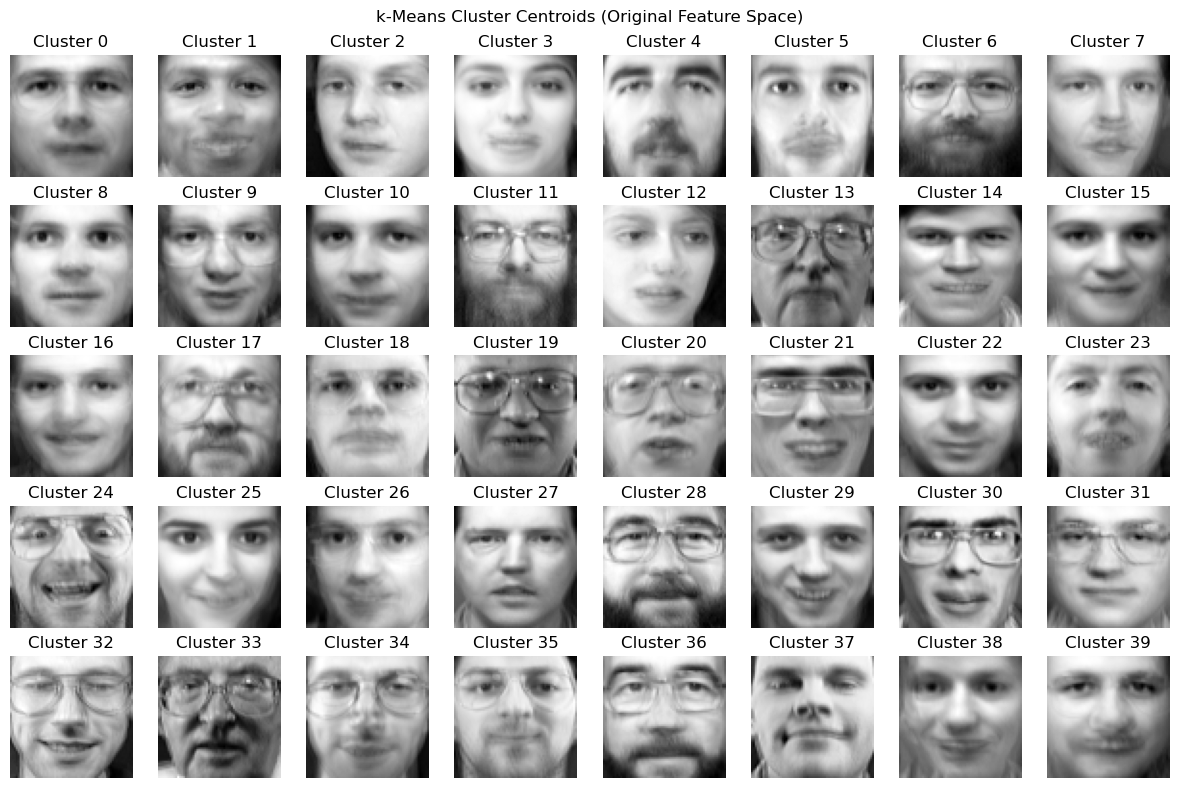

In [ ]:
fig, axes = plt.subplots(5, 8, figsize=(12, 8))
for idx, ax in enumerate(axes.flat):
    ax.imshow(kmeans.cluster_centers_[idx].reshape(64,64), cmap='gray')
    ax.set_title(f'Cluster {idx}')
    ax.axis('off') 

plt.suptitle('k-Means Cluster Centroids (Original Feature Space)')
plt.tight_layout()
plt.show()

The k-means centroids look like average faces for each cluster, so they tend to be smoother and more face-like. Eigenfaces are not averages of clusters, they are global variance directions and can look like lighting or edge patterns. This is why centroids resemble faces more directly, while eigenfaces can look abstract and highlight contrast patterns.

### 2.5 Applying K-Means Clustering to the PCA-reduced feature space.

Next, we will apply k-Means clustering to the PCA-reduced feature space, using k value equal to the number of classes.

In [ ]:
X_reduced = pca.transform(X)[:, :d]

kmeans_pca = KMeans(n_clusters=k, random_state=42)
kmeans_pca.fit(X_reduced)

score_pca = silhouette_score(X_reduced, kmeans_pca.labels_)
print("Silhouette Score:", score_pca)

Silhouette Score: 0.17359658


Now that both k‑means models are fitted, we can compare their silhouette scores numerically and visually using silhouette diagrams.

Without pca: 0.12942750751972198 
 with pca: 0.1735965758562088


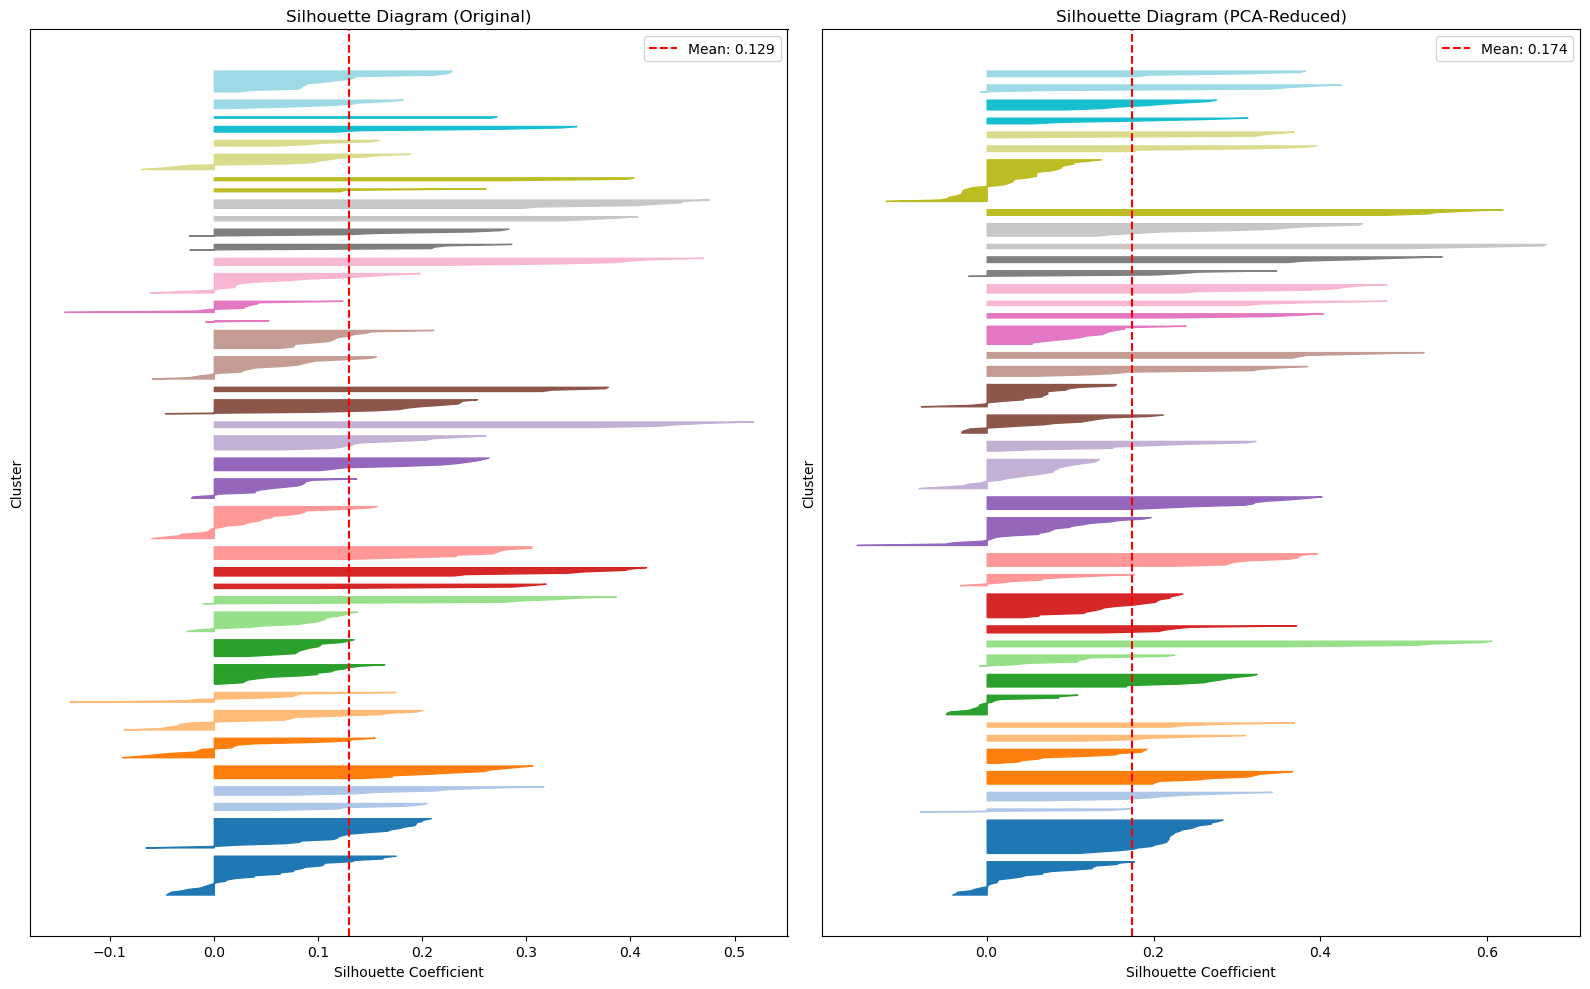

In [ ]:
print(f'Without pca: {score} \n with pca: {score_pca}')

def plot_silhouette_graph(data, labels, score, title, ax):
    n_cluster = len(np.unique(labels))
    silhouette_values = silhouette_samples(data, labels)
    y_lower = 10

    for i in range(n_cluster):
        cluster_vals = np.sort(silhouette_values[labels == i])
        size = cluster_vals.shape[0]
        y_upper = y_lower + size
        color = cm.tab20(i / n_cluster)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, color=color)
        y_lower = y_upper + 5
    ax.axvline(x=score, color='red', linestyle='--', label=f'Mean: {score:.3f}')
    ax.set_title(title)
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(16,10))
plot_silhouette_graph(X, kmeans.labels_, score, 'Silhouette Diagram (Original)', axes[0])
plot_silhouette_graph(X_reduced, kmeans_pca.labels_, score_pca, 'Silhouette Diagram (PCA-Reduced)', axes[1])
plt.tight_layout()
plt.show()

### 2.6 Observation & Comments

#### The Effect of PCA on k-Means Clustering
Applying PCA notably improved clustering performance, increasing the silhouette score from 0.129 to 0.174. By reducing the feature space from 4096 dimensions to just 123 (while still retaining >95% variance), PCA successfully mitigates the *curse of dimensionality*. Distances in this highly compact space become more meaningful, allowing k-Means to form tighter, denser clusters.

However, the overall silhouette score remains relatively low. This is expected given the dataset's complexity: we are attempting to separate 40 distinct classes using only 400 highly similar images. Because PCA is designed to maximize variance rather than explicit class separability, heavily overlapping classes in the original space remain entangled in the reduced space. Dimensionality reduction alone cannot perfectly separate features if the underlying subjects naturally look alike.

#### Trade-offs: Raw Features vs. PCA-Reduced Space
- **Advantages:** PCA dramatically reduces training time and memory usage. It resolves multicollinearity and acts as a noise filter by dropping less significant components, which directly contributes to the improved silhouette score.
- **Disadvantages:** The reduction inevitably discards fine, discriminative facial details (which is why eigenfaces look abstract compared to standard clusters). It also reduces the human interpretability of the features and can disrupt local image structures, limiting the absolute quality of the clustering.

## Conclusion

In this assignment, we explored both supervised ensemble learning and unsupervised clustering. 

We first explore how ensemble methods, AdaBoost and Random Forests improve predictive accuracy over a single Decision Tree by mitigating bias and variance. We also highlighted the importance of proper categorical encoding, which ensures models learn meaningful continuous patterns rather than artificial ordinal relationships.

Next, we applied PCA to high-dimensional image data prior to k-Means clustering. While PCA effectively reduced computational complexity, removed noise, and improved quantitative clustering metrics, it also highlighted a key limitation: capturing overall dataset variance does not inherently guarantee clean class separation. 